# Credit Risk Prediction Project

## Machine Learning Project: Predicting Credit Card Defaults

This project applies various machine learning techniques to predict credit card defaults using the [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). The goal is to build and evaluate multiple models to identify customers at risk of defaulting on their credit card payments.

## Table of Contents
1. [Problem Definition and Dataset Overview](#1-problem-definition-and-dataset-overview)
2. [Data Splitting](#2-data-splitting)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Preprocessing and Transformations](#5-preprocessing-and-transformations) 
6. [Baseline Model](#6-baseline-model)
7. [Linear Models](#7-linear-models)
8. [Model Comparison](#8-model-comparison)
9. [Feature Selection](#9-feature-selection)
10. [Hyperparameter Optimization](#10-hyperparameter-optimization)
11. [Model Interpretation and Feature Importances](#11-model-interpretation-and-feature-importances) 
12. [Final Evaluation on Test Set](#12-final-evaluation-on-test-set)
13. [Summary of Results](#13-summary-of-results)
14. [Project Takeaways](#14-project-takeaways)

## Project Overview

This project demonstrates a complete machine learning workflow for credit risk prediction, including:
- Exploratory data analysis
- Feature engineering
- Model selection and comparison
- Hyperparameter optimization
- Model interpretation using SHAP values
- Performance evaluation on test data

The project uses various machine learning algorithms including Logistic Regression, XGBoost, Support Vector Machines, and Decision Trees to predict credit card defaults.

## Imports

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.svm import SVC

## Introduction

This project applies machine learning techniques to predict credit card defaults. The goal is to build models that can identify customers at risk of defaulting on their credit card payments, which is crucial for financial institutions to manage risk effectively.

### Project Approach

1. **Data Understanding**: We start by exploring the dataset, understanding the features, and identifying patterns and potential issues.
2. **Feature Engineering**: We create new features that may improve model performance, such as aggregated payment delays and utilization ratios.
3. **Model Development**: We experiment with multiple algorithms including linear models, tree-based ensembles, and support vector machines.
4. **Model Optimization**: We perform hyperparameter tuning to find the best configurations for our models.
5. **Model Interpretation**: We use SHAP values to understand which features are most important for predictions.
6. **Evaluation**: We evaluate final model performance on a held-out test set.

### Key Considerations

- The dataset exhibits class imbalance (approximately 78% non-defaults, 22% defaults), so we use F1 score as our primary metric.
- We focus on creating reproducible, well-documented code that clearly explains our decision-making process.
- All hyperparameter choices are based on systematic optimization experiments that are included in the notebook. 

## 1. Problem Definition and Dataset Overview

### Problem Statement

This project focuses on predicting credit card defaults using the [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). The dataset contains 30,000 examples with 24 features, and the goal is to predict whether a person will default (fail to pay) their credit card bills in the next month. This is a binary classification problem where the target variable is labeled "default.payment.next.month".

### Dataset Description

The dataset includes:
- **Demographic features**: Age, sex, education, marriage status
- **Credit information**: Credit limit (LIMIT_BAL)
- **Payment history**: Repayment status for the past 6 months (PAY_0 to PAY_6)
- **Bill amounts**: Bill statement amounts for the past 6 months (BILL_AMT1 to BILL_AMT6)
- **Payment amounts**: Amount of previous payments (PAY_AMT1 to PAY_AMT6)

### Initial Thoughts

The dataset appears well-suited for predicting credit risk, with repayment status and bill amounts likely being the strongest indicators. While demographic features might also provide useful insights, a key challenge is the expected class imbalance, as defaults are typically less common. Additionally, bill amounts and payments are probably highly correlated, which will need careful handling during feature engineering and modeling. 

In [7]:
data = pd.read_csv("data/UCI_Credit_Card.csv", index_col=0)
data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Data Splitting

We split the data into training (70%) and test (30%) sets with a fixed random state for reproducibility.  

In [8]:
X = data.drop(columns=['default.payment.next.month'])
y = data['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state = 123)


## 3. Exploratory Data Analysis

Here, we perform exploratory data analysis to understand the dataset structure, identify patterns, and determine appropriate evaluation metrics. 

In [9]:
print(f"The shape of the train set is {X_train.shape}") #getting an overview and summary of the training set
X_train.info()


print(f"there are {X_train.isnull().sum().sum()} missing values")   # checking for missing values

print(y_train.value_counts(normalize=True))  # checking the ratio of the values in the training target set

print( X_train.describe())

X_train.head()

The shape of the train set is (21000, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 21000 entries, 16396 to 19967
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  21000 non-null  float64
 1   SEX        21000 non-null  int64  
 2   EDUCATION  21000 non-null  int64  
 3   MARRIAGE   21000 non-null  int64  
 4   AGE        21000 non-null  int64  
 5   PAY_0      21000 non-null  int64  
 6   PAY_2      21000 non-null  int64  
 7   PAY_3      21000 non-null  int64  
 8   PAY_4      21000 non-null  int64  
 9   PAY_5      21000 non-null  int64  
 10  PAY_6      21000 non-null  int64  
 11  BILL_AMT1  21000 non-null  float64
 12  BILL_AMT2  21000 non-null  float64
 13  BILL_AMT3  21000 non-null  float64
 14  BILL_AMT4  21000 non-null  float64
 15  BILL_AMT5  21000 non-null  float64
 16  BILL_AMT6  21000 non-null  float64
 17  PAY_AMT1   21000 non-null  float64
 18  PAY_AMT2   21000 non-null  float64
 19  PAY_A

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,,,,,,,,,,,,,,,,,,,,,
16396,320000.0,2,1,2,36,0,0,0,0,0,...,28695.0,19370.0,10155.0,3788.0,5000.0,5018.0,1000.0,3000.0,0.0,7013.0
21449,440000.0,2,1,2,30,-1,-1,-1,0,0,...,87426.0,171244.0,150897.0,117870.0,612.0,87426.0,130007.0,3018.0,15000.0,51663.0
20035,160000.0,2,3,1,44,-2,-2,-2,-2,-2,...,-18.0,-18.0,-18.0,-18.0,0.0,0.0,0.0,0.0,0.0,0.0
25756,120000.0,2,2,1,30,0,0,0,0,0,...,104694.0,103058.0,71095.0,47379.0,3706.0,5502.0,4204.0,3017.0,2005.0,1702.0
1439,50000.0,1,2,2,54,1,2,0,0,0,...,27168.0,27585.0,27910.0,27380.0,0.0,1400.0,1200.0,1500.0,1000.0,1500.0


Since there is class imbalance and the “yes” class is more important, we are going to use the F1 score as our metric because it balances precision (avoiding false positives) and recall (catching true positives), which is crucial when missing defaults or wrongly predicting non-defaults can both have serious consequences.

In [10]:
data.info()
numerical_features = [
    'LIMIT_BAL', 'AGE', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

ordinal_features = [
    'PAY_0', 'PAY_2', 'PAY_3', 
    'PAY_4', 'PAY_5', 'PAY_6', 
]

categorical_features = [
    'SEX', 'MARRIAGE', 'EDUCATION'
]

target_feature = ['default.payment.next.month']

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 no

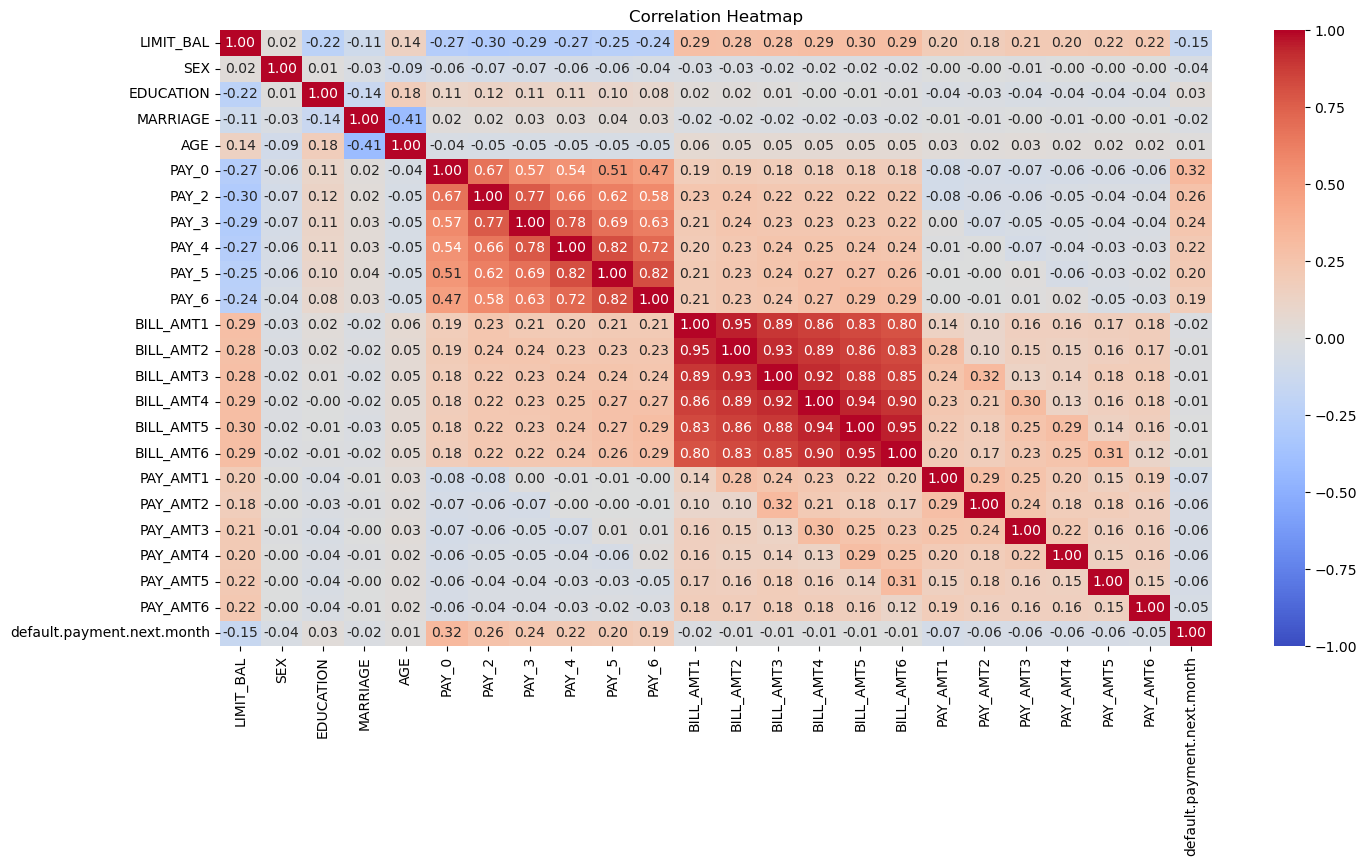

In [11]:
correlation_matrix = data.corr()

# Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap reveals strong correlations between consecutive BILL_AMT columns and consecutive PAY columns, which is expected given their temporal nature. This suggests we may benefit from feature engineering to create aggregated features.

In [12]:
X_train.describe()
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(X_train[col].value_counts())

SEX
2    12616
1     8384
Name: count, dtype: int64
EDUCATION
2    9815
1    7433
3    3416
5     210
4      81
6      35
0      10
Name: count, dtype: int64
MARRIAGE
2    11210
1     9527
3      229
0       34
Name: count, dtype: int64


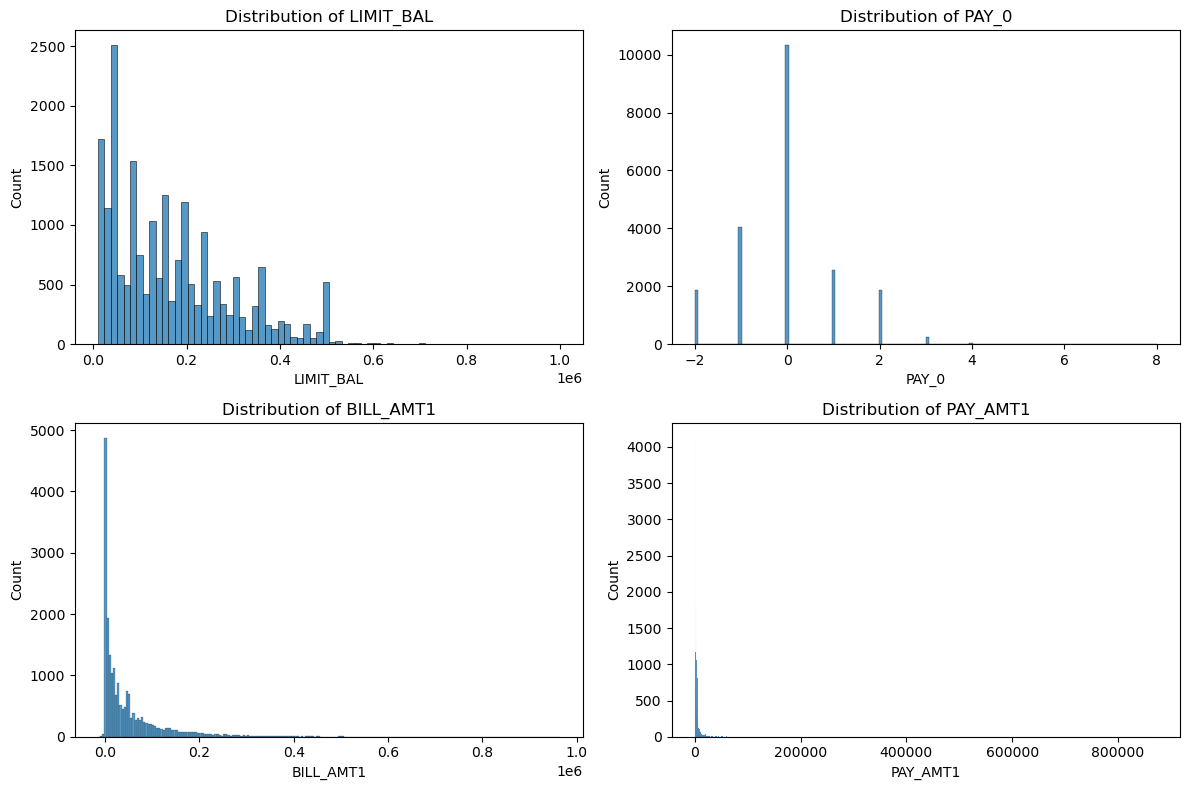

In [13]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['LIMIT_BAL', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1'], 1):
    plt.subplot(2, 2, i)
    sns.histplot(X_train[feature], kde=False)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

The dataset reveals a noticeable class imbalance, with approximately 77.7% non-defaults and 22.3% defaults, highlighting the need for metrics like F1 score or recall over simple accuracy. The mean credit limit is around 167,880 NT dollars, but with a wide range from 10,000 to 1,000,000 NT dollars, suggesting considerable variation in customer profiles. This range may also indicate potential outliers that could impact model performance. Repayment status features (PAY_0 to PAY_6) show that most customers pay on time, but spikes in 1-2 month delays suggest short-term payment struggles are common.

Visualizing numerical features by class shows that higher credit limits and bill amounts are more frequent among non-defaults, but defaults still occur across all ranges, indicating these features alone may not strongly distinguish between classes. Standardizing the data improved the clarity of these patterns, revealing meaningful trends that were less visible on the original scale. Overall, the combination of imbalanced classes, variable distributions, and potential outliers will require thoughtful handling when building a predictive model.

In [14]:
scroring_metric = 'f1'

## 4. Feature Engineering

We create new features that aggregate information across the temporal payment and bill amount features to capture overall customer behavior patterns. 

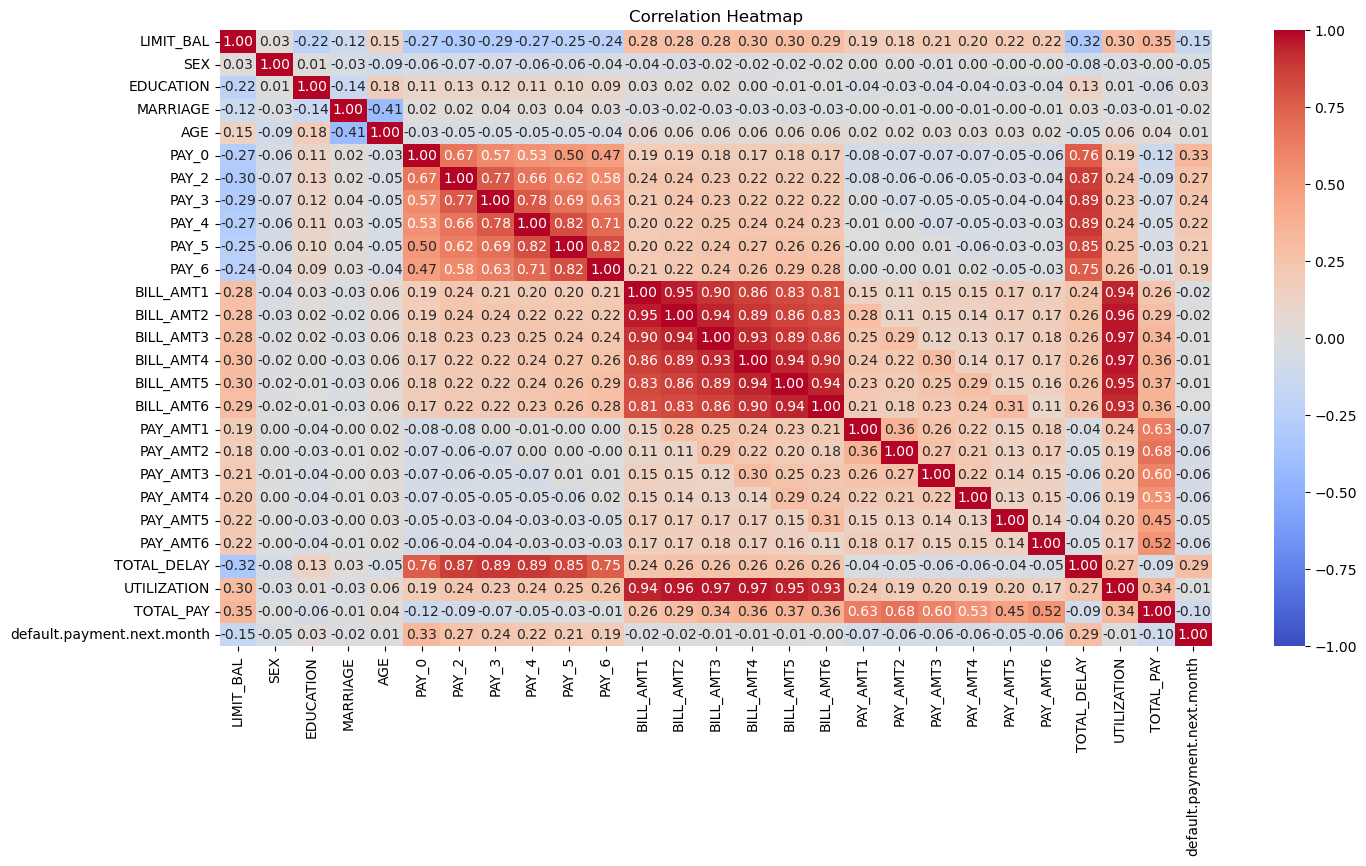

In [15]:
X_train['TOTAL_DELAY'] = X_train[ordinal_features[0:5]].sum(axis=1)
X_train['UTILIZATION'] = X_train[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                        'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
X_train['TOTAL_PAY'] = X_train[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)


X_test['TOTAL_DELAY'] = X_test[ordinal_features[0:5]].sum(axis=1)
X_test['UTILIZATION'] = X_test[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                        'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1) / X_test['LIMIT_BAL']
X_test['TOTAL_PAY'] = X_test[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)

correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()

# Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Verifying the correlation of newly added features to ensure they provide meaningful information.

## 5. Preprocessing and Transformations

We identify different feature types and apply appropriate transformations:
- **Numerical features**: Standardized using StandardScaler
- **Ordinal features**: Encoded using OrdinalEncoder
- **Categorical features**: One-hot encoded using OneHotEncoder 

In [16]:
numerical_features = [
    'LIMIT_BAL', 'AGE', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TOTAL_DELAY', 'UTILIZATION', 'TOTAL_PAY'
]

ordinal_features = [
    'PAY_0', 'PAY_2', 'PAY_3', 
    'PAY_4', 'PAY_5', 'PAY_6', 
]

categorical_features = [
    'SEX', 'MARRIAGE','EDUCATION'
]

target_feature = ['default.payment.next.month']




In [17]:

# Preprocessor for numerical features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy ="mean"), 
    StandardScaler()
)

# Preprocessor for ordinal features

ordinal_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
)

# Preprocessor for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

# Combine all transformers
preprocessor = make_column_transformer(
    (numeric_transformer, numerical_features),
    (ordinal_transformer, ordinal_features),
    (categorical_transformer, categorical_features)
)

preprocessor



ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                                  'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
                                  'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                                  'PAY_AMT6', 'TOTAL_DELAY', 'UTILIZATION',
                                  'TOTAL_PAY']),
                                ('pipeline-2',
                                 Pip...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                                  'PAY_6']),
                                ('pipeline-3',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['SEX', 'MARRIAGE', 'EDUCATION'])])

## 6. Baseline Model

We establish a baseline using scikit-learn's DummyClassifier to compare against more sophisticated models.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

dummy = DummyClassifier(strategy="most_frequent")
base_pipe = make_pipeline(preprocessor, dummy)


base_scores = cross_validate(base_pipe, X_train,y_train, return_train_score=True,scoring=scroring_metric)
pd.DataFrame(base_scores)

# y_pred = base_pipe.predict(X_test)

# # Performance Report
# print(classification_report(y_test, y_pred))

# # F1 Score (since we care about class imbalance)
# print(f"Baseline F1 Score: {f1_score(y_test, y_pred):.2f}")

,fit_time,score_time,test_score,train_score
0,0.028424,0.007271,0.0,0.0
1,0.019941,0.008444,0.0,0.0
2,0.019923,0.006498,0.0,0.0
3,0.018789,0.006898,0.0,0.0
4,0.018996,0.006458,0.0,0.0


## 7. Linear Models

We start with Logistic Regression as our first real model. We perform hyperparameter tuning to find the optimal regularization strength (C parameter) and evaluate performance using cross-validation.

In [21]:


linear_model = LogisticRegression(max_iter=500)

linear_pipe = make_pipeline(preprocessor, linear_model)

# Hyperparameter tuning for complexity (C)
param_dist = {
    'logisticregression__C': np.logspace(-4, 4, 30)  # 30 values between 1e-4 and 1e4

}

random_search = RandomizedSearchCV(
    linear_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=123,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('pipeline-1',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer()),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               ['LIMIT_BAL',
                                                                                'AGE',
                                                                                'BILL_AMT1',
                                                                                'BILL_AMT2',
                                                                                'BILL_AMT3',
                                                                                'BILL_AMT4',
                                                                                'BILL_AMT5',
                                                                                'BILL_AMT6',
                                                                                'PAY_AMT1',
                                                                                'PAY_AMT2',
                                                                                'PAY_AMT3',
                                                                                'PAY_AMT4',
                                                                                'PAY_AMT5'...
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04])},
                   random_state=123, scoring='f1')

In [22]:


best_model = random_search.best_estimator_

# Cross-validation scores
lr_scores = cross_validate(best_model, X_train, y_train, cv=5, scoring='f1',return_train_score=True)
lr_results = pd.DataFrame(lr_scores)
best_c = random_search.best_params_['logisticregression__C']

print(lr_results)
print(f"Best C Value: {random_search.best_params_['logisticregression__C']:.4f}")
print(f"Mean F1 Score (Train Set): {lr_results['train_score'].mean():.2f} ± {lr_results['train_score'].std():.2f}")
print(f"Mean F1 Score (CV): {lr_results['test_score'].mean():.2f} ± {lr_results['test_score'].std():.2f}")

# Step 4: Summarize Results
print("\nSummary:")
print("- The best `C` value found was:", best_c)
print(f"- The average F1 score on the train set was {lr_results['train_score'].mean():.2f}")
print(f"- The average F1 score on cross-validation folds was {lr_results['test_score'].mean():.2f}")
print("- The small standard deviation suggests stable performance across folds.")


   fit_time  score_time  test_score  train_score
0  0.135800    0.008407    0.386399     0.391238
1  0.136225    0.007538    0.379045     0.382193
2  0.108567    0.007620    0.389105     0.372020
3  0.119462    0.007311    0.382946     0.371138
4  0.115086    0.006971    0.359055     0.379156
Best C Value: 0.1083
Mean F1 Score (Train Set): 0.38 ± 0.01
Mean F1 Score (CV): 0.38 ± 0.01

Summary:
- The best `C` value found was: 0.1082636733874054
- The average F1 score on the train set was 0.38
- The average F1 score on cross-validation folds was 0.38
- The small standard deviation suggests stable performance across folds.


## 8. Model Comparison

We compare multiple models including tree-based ensembles, support vector machines, and decision trees. We evaluate each model in terms of performance, overfitting/underfitting, and computational efficiency. 

From the results, XGBoost shows the highest cross-validation F1 score (0.463), making it the best-performing model in terms of prediction strength. However, it also shows some overfitting, with a notable gap of 0.29 between its train and CV scores. This suggests that while XGBoost effectively captures patterns in the data, there’s room to improve its generalization through further tuning or regularization. SVC performs almost as well as XGBoost, with a CV F1 score of 0.459. Importantly, SVC has a minimal overfitting gap (0.009), indicating it’s learning robust patterns without excessive memorization, making it a strong contender despite its higher training and scoring times.

On the other hand, DecisionTree shows severe overfitting, with an extremely high train F1 score (0.999) but a significantly lower CV score (0.407), signaling that it struggles to generalize. Logistic Regression, while stable and consistent, continues to show relatively weak performance with an F1 score of 0.379. However, it has almost no overfitting, demonstrating its reliability despite being less powerful overall. In conclusion, XGBoost stands out for its performance, while SVC offers the best balance between accuracy and generalization.

In [24]:
from sklearn.svm import SVC

In [25]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

results = []
models_2 = {
    'LogisticRegression': make_pipeline(preprocessor,LogisticRegression(max_iter=500, C=best_c)),
    'XGBoost': make_pipeline(preprocessor,XGBClassifier(n_estimators=100, random_state=123)),
    'SVC': make_pipeline(preprocessor,SVC()),
    'DecisionTree': make_pipeline(preprocessor,DecisionTreeClassifier(random_state=123))
}


for name, model in models_2.items():
    cv_scores = cross_validate(
        model, X_train, y_train, cv=5, scoring='f1',
        return_train_score=True, n_jobs=-1
    )
    
    results.append({
        'Model': name,
        'Mean Train F1': np.mean(cv_scores['train_score']),
        'Mean CV F1': np.mean(cv_scores['test_score']),
        'Overfitting Gap': np.mean(cv_scores['train_score']) - np.mean(cv_scores['test_score']),
        'Train Time (s)': np.mean(cv_scores['fit_time']),
        'Score Time (s)': np.mean(cv_scores['score_time'])
    })


results_df = pd.DataFrame(results).sort_values('Mean CV F1', ascending=False)
print(results_df)

                Model  Mean Train F1  Mean CV F1  Overfitting Gap  \
1             XGBoost       0.756936    0.463479         0.293457   
2                 SVC       0.468990    0.459548         0.009442   
3        DecisionTree       0.998665    0.407213         0.591452   
0  LogisticRegression       0.379184    0.379116         0.000068   

   Train Time (s)  Score Time (s)  
1        0.443198        0.025453  
2       13.114007        4.577919  
3        0.651416        0.013717  
0        0.170389        0.011955  


In [26]:
...

Ellipsis

## 9. Feature Selection

We experiment with feature selection techniques to determine if reducing the feature set improves model performance, trying both automated methods (RFECV) and manual feature selection based on domain knowledge. 

I attempted feature selection using RFECV with both LogisticRegression and RandomForestClassifier to assess its impact on model performance. For LogisticRegression, the mean CV F1 score remained almost identical after feature selection (0.379 vs 0.378), indicating that RFECV had no meaningful effect. For RandomForest, the CV F1 score improved slightly from 0.425 to 0.429, but the model continued to show severe overfitting, with minimal reduction in the overfitting gap. Since neither model demonstrated significant improvement with feature selection, it does not appear to be beneficial for this dataset. As a result, I may exclude feature selection from my pipeline in future steps unless further experimentation shows otherwise.

I also attempted manual selection and only kept the aggregated features but that also only made everything worse. As seen in the table below.

In [27]:
from sklearn.feature_selection import RFECV

In [28]:
# linear_pipe_rfecv = make_pipeline(
#     preprocessor,
#     RFECV(LogisticRegression(max_iter=500,C=random_search.best_params_['logisticregression__C']), cv=5, scoring='f1'),
#     LogisticRegression(max_iter=500,C=random_search.best_params_['logisticregression__C'])
# )

# # RandomForest with RFECV
# rf_pipe_rfecv = make_pipeline(
#     preprocessor,
#     RFECV(RandomForestClassifier(n_estimators=10, random_state=123), cv=5, scoring='f1',n_jobs=-1),
#     RandomForestClassifier(n_estimators=10, random_state=123)
# )

In [29]:
# models = {
#     'LogisticRegression + RFECV': linear_pipe_rfecv,
#     'RandomForest + RFECV': rf_pipe_rfecv
# }

# results = []

# for name, model in models.items():
#     cv_scores = cross_validate(
#         model, X_train, y_train, cv=5, scoring='f1',
#         return_train_score=True, n_jobs=-1
#     )
    
#     results.append({
#         'Model': name,
#         'Mean Train F1': np.mean(cv_scores['train_score']),
#         'Mean CV F1': np.mean(cv_scores['test_score']),
#         'Overfitting Gap': np.mean(cv_scores['train_score']) - np.mean(cv_scores['test_score'])
#     })

# # Display results
# results_df = pd.DataFrame(results).sort_values('Mean CV F1', ascending=False)
# print(results_df)

In [30]:
X_train_reduced = X_train.drop(['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                                'PAY_0', 'PAY_2', 'PAY_3', 
                                'PAY_4', 'PAY_5', 'PAY_6'], axis=1)

X_test_reduced = X_test.drop(['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                              'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                              'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                              'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                              'PAY_0', 'PAY_2', 'PAY_3', 
                              'PAY_4', 'PAY_5', 'PAY_6'], axis=1)

numerical_features_reduced = [
     'TOTAL_DELAY', 'UTILIZATION', 'TOTAL_PAY'
]



preprocessor_reduced = make_column_transformer(
    (numeric_transformer, numerical_features_reduced),
    (categorical_transformer, categorical_features)
)


results_reduced = []
models_3 = {
    'LogisticRegression': make_pipeline(preprocessor_reduced,LogisticRegression(max_iter=500, C=best_c)),
    'XGBoost': make_pipeline(preprocessor_reduced,XGBClassifier(n_estimators=100, random_state=123)),
    'SVC': make_pipeline(preprocessor_reduced,SVC()),
    'DecisionTree': make_pipeline(preprocessor_reduced,DecisionTreeClassifier(random_state=123))
}


for name, model in models_3.items():
    cv_scores = cross_validate(
        model, X_train_reduced, y_train, cv=5, scoring='f1',
        return_train_score=True, n_jobs=-1
    )
    
    results_reduced.append({
        'Model': name,
        'Mean Train F1': np.mean(cv_scores['train_score']),
        'Mean CV F1': np.mean(cv_scores['test_score']),
        'Overfitting Gap': np.mean(cv_scores['train_score']) - np.mean(cv_scores['test_score']),
        'Train Time (s)': np.mean(cv_scores['fit_time']),
        'Score Time (s)': np.mean(cv_scores['score_time'])
    })


results_df = pd.DataFrame(results_reduced).sort_values('Mean CV F1', ascending=False)
print(results_df)


                Model  Mean Train F1  Mean CV F1  Overfitting Gap  \
1             XGBoost       0.581686    0.410217         0.171469   
2                 SVC       0.378612    0.370735         0.007877   
3        DecisionTree       0.977874    0.370579         0.607294   
0  LogisticRegression       0.288610    0.289239        -0.000629   

   Train Time (s)  Score Time (s)  
1        0.199088        0.022277  
2       11.245270        2.491492  
3        0.121169        0.007987  
0        0.072131        0.012087  


## 10. Hyperparameter Optimization

We perform hyperparameter optimization using RandomizedSearchCV to find the best configuration for our models, optimizing multiple hyperparameters simultaneously for our best-performing models. 

In [31]:

param_grid = {
    'xgbclassifier__n_estimators': [50, 100, 200, 300],
    'xgbclassifier__max_depth': [3, 5, 7, 10],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgbclassifier__subsample': [0.6, 0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0],
    'xgbclassifier__gamma': [0, 0.1, 0.3, 0.5]
}

# Initialize model
xgb_model = models_2['XGBoost']

# RandomizedSearchCV setup
random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=123
)

# Fit the model
random_search_xgb.fit(X_train, y_train)

# Best model and results
best_xgb_params = random_search_xgb.best_params_
best_xgb = random_search_xgb.best_estimator_

print("Best Hyperparameters:", random_search_xgb.best_params_)
print("Best Cross-Validation Score:", random_search_xgb.best_score_)
best_xgb

Best Hyperparameters: {'xgbclassifier__subsample': 0.6, 'xgbclassifier__n_estimators': 50, 'xgbclassifier__max_depth': 5, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__gamma': 0.5, 'xgbclassifier__colsample_bytree': 0.6}
Best Cross-Validation Score: 0.4797313396198765


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'AGE',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6',
                                                   'TOTAL_DELAY', 'UTILIZA...
                               feature_types=None, gamma=0.5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None, random_state=123, ...))])

In [32]:
# param_grid = {
#     'svc__C': [0.1, 1, 10, 100, 1000],
#     'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
# }

# # Initialize model
# svc_model = models_2['SVC']

# # RandomizedSearchCV setup
# random_search_svc = RandomizedSearchCV(
#     svc_model,
#     param_grid,
#     n_iter=30,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     random_state=123
# )

# # Fit the model
# random_search_svc.fit(X_train, y_train)

# # Best model and results
# best_svc = random_search_svc.best_estimator_

# print("Best Hyperparameters:", random_search_svc.best_params_)
# print("Best Cross-Validation Score:", random_search_svc.best_score_)

## 11. Model Interpretation and Feature Importances

We use SHAP (SHapley Additive exPlanations) values to interpret our model predictions and understand which features are most important for the model's decisions. 

_The SHAP waterfall plot highlights key features influencing the XGBoost model’s predictions. Notably, BILL_AMT4, BILL_AMT2, and BILL_AMT6 are the strongest positive contributors, suggesting that higher values in these features increase the predicted score. Conversely, PAY_0, PAY_AMT2, and TOTAL_DELAY contribute negatively, indicating that delays and certain payment patterns decrease the likelihood of a positive outcome. While the engineered feature TOTAL_DELAY played a meaningful role, individual bill amounts and payment records appeared more significant. Overall, the model’s prediction score reflects a balance between these features, with past repayment behavior and bill amounts emerging as crucial indicators. Further exploration of SHAP values across multiple samples could help confirm these patterns.
The SHAP summary plot highlights key features influencing the XGBoost model’s predictions. PAY_0, TOTAL_DELAY, and LIMIT_BAL show the strongest impact on the model’s output. Notably, higher values in PAY_0 and TOTAL_DELAY are linked to negative SHAP values, indicating they increase the likelihood of default. Conversely, LIMIT_BAL exhibits mixed behavior, suggesting complex interactions with other features. Additionally, while BILL_AMT1, PAY_AMT2, and PAY_AMT3 show some impact, their influence is relatively smaller. The presence of strong negative SHAP values for certain features suggests that repayment delays and high credit limits are key risk indicators. This plot underscores the importance of analyzing both numerical features and engineered delay/payment-related features for predicting default risk.

 98%|===================| 20498/21000 [00:16<00:00]        

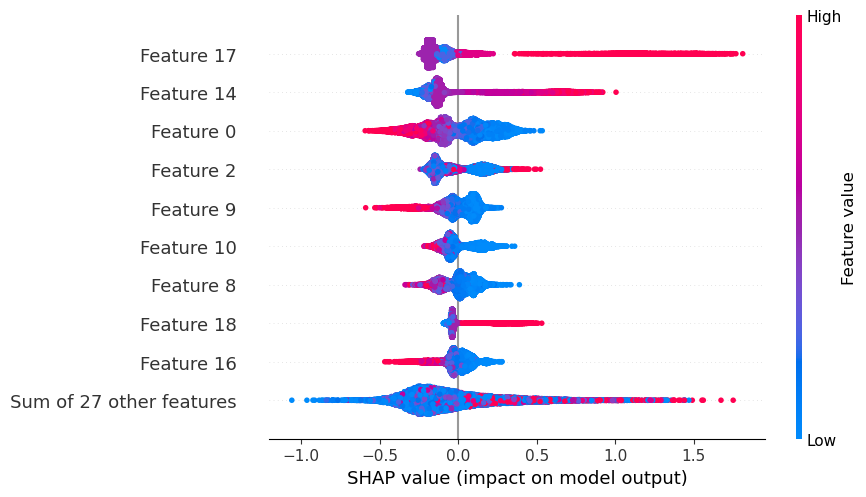

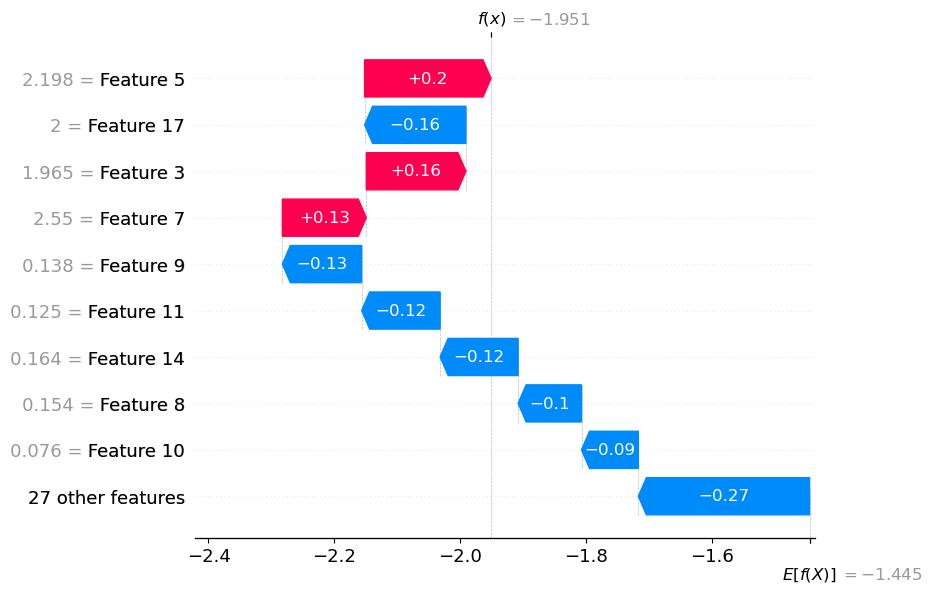

In [39]:
import shap
# Fit the preprocessor before transforming
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Extract and fit the XGBoost model from pipeline
xgb_model = best_xgb.named_steps['xgbclassifier']
xgb_model.fit(X_train_transformed, y_train)

# Initialize SHAP explainer
explainer = shap.Explainer(xgb_model, X_train_transformed)

# Compute SHAP values for both sets
shap_values_train = explainer(X_train_transformed)
shap_values_test = explainer(X_test_transformed)

# Feature importance plot (summary plot)
shap.plots.beeswarm(shap_values_train)

# Waterfall plots for individual predictions
ex1_idx = 17
ex2_idx = 1042
shap.plots.waterfall(shap_values_train[ex1_idx])




## 12. Final Evaluation on Test Set
 

The test F1 score of 0.4662 aligns closely with the cross-validation F1 score of 0.4635 from the previous evaluation, indicating that the model’s performance generalizes reasonably well to unseen data. This consistency suggests that the model was not heavily overfitting to the training data and that the validation process was effective. While the precision for class 1 is decent, the recall is notably low, meaning the model struggles to identify positive cases effectively. This may be a consequence of class imbalance, which is common in credit risk datasets. Given the alignment between test and validation scores, optimization bias seems minimal, although the relatively low recall indicates there may still be room for improvement. Strategies like rebalancing the data, adjusting class weights, or experimenting with alternative models could help enhance recall without compromising overall performance.

Test F1 Score: 0.4662
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      7052
           1       0.65      0.36      0.47      1948

    accuracy                           0.82      9000
   macro avg       0.74      0.65      0.68      9000
weighted avg       0.80      0.82      0.80      9000



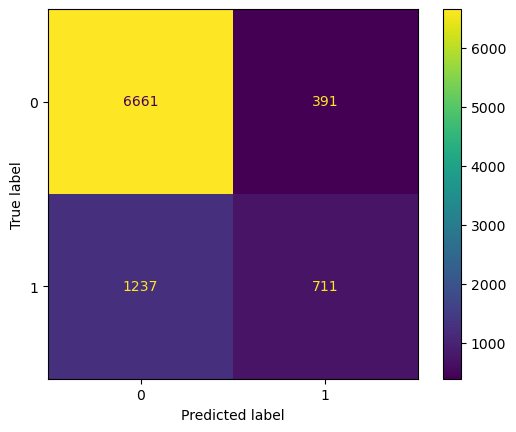

In [48]:

best_xgb_model = best_xgb.named_steps['xgbclassifier']
best_xgb_model.fit(X_train_transformed, y_train)

y_test_pred = best_xgb_model.predict(X_test_transformed)

test_f1 = f1_score(y_test, y_test_pred)
print(f"Test F1 Score: {test_f1:.4f}")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_xgb_model, X_test_transformed, y_test)
plt.show()

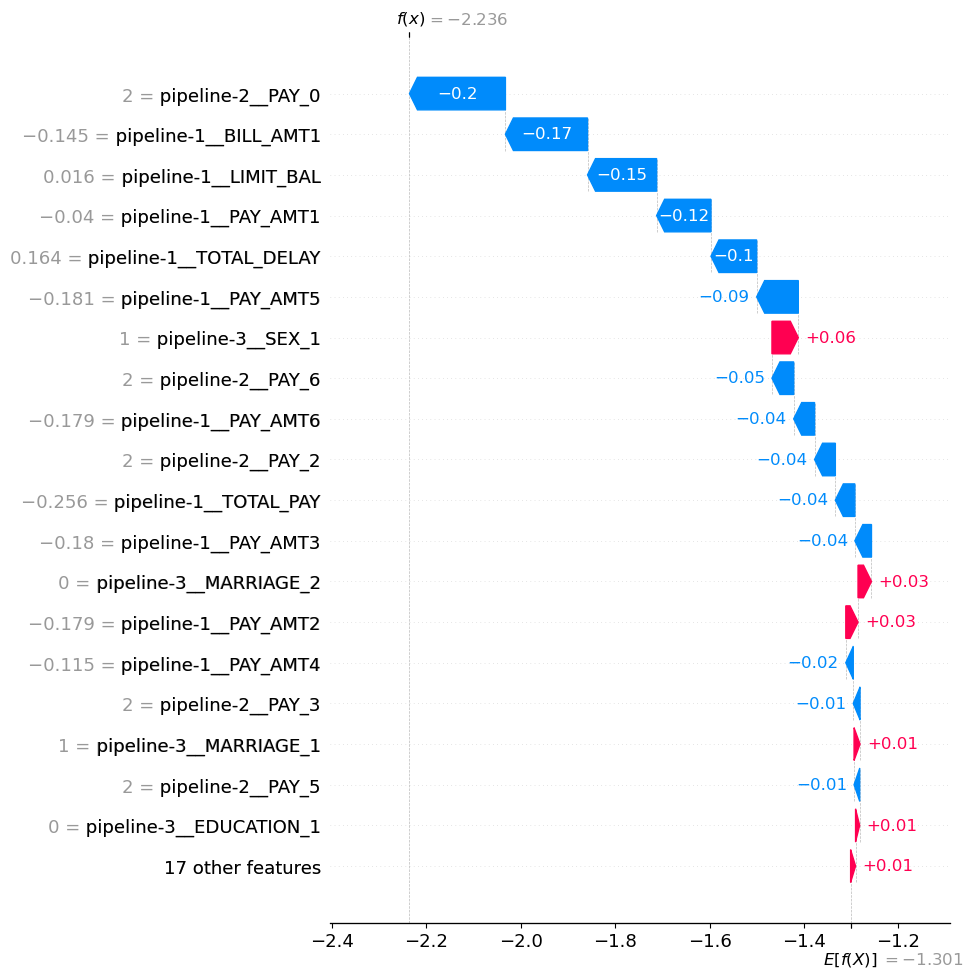

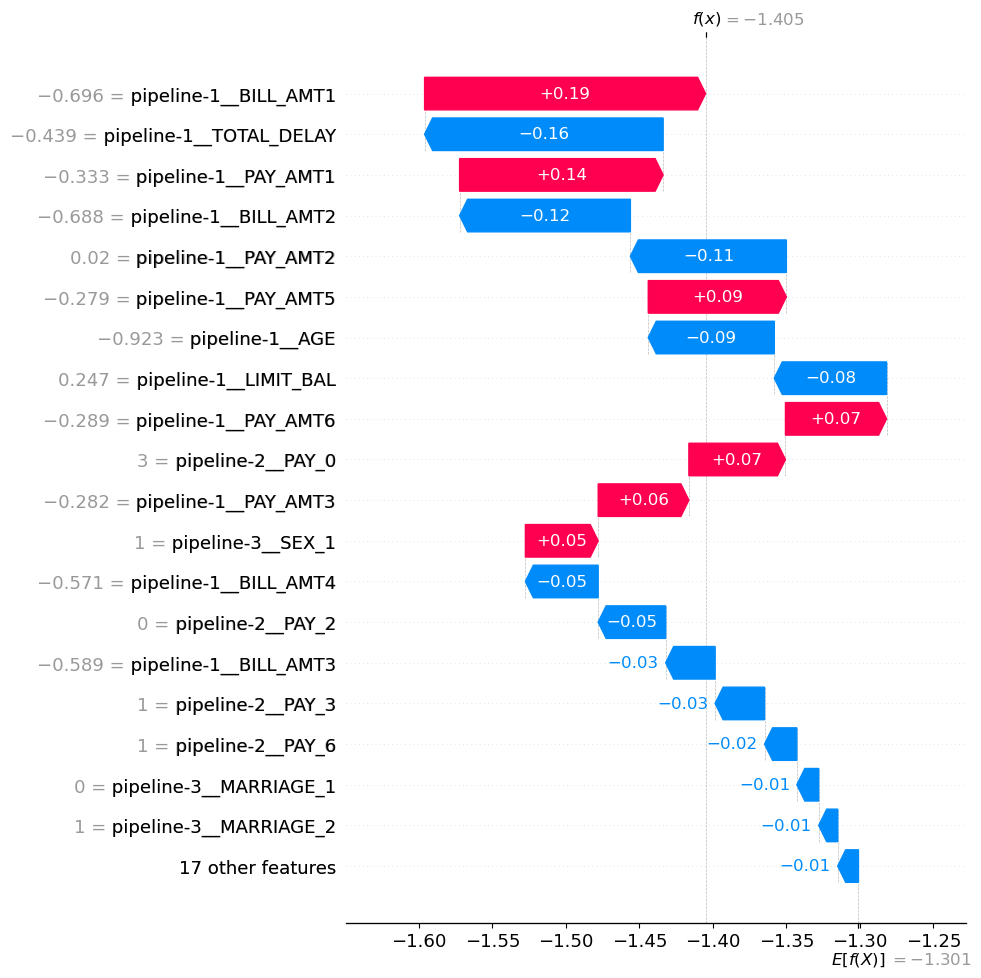

In [49]:
# Transform the data and convert it back to a DataFrame with correct feature names
X_test_transformed = pd.DataFrame(preprocessor.transform(X_test), 
                                  columns=preprocessor.get_feature_names_out())

# Initialize SHAP explainer
explainer = shap.Explainer(best_xgb.named_steps['xgbclassifier'], X_test_transformed)

# Compute SHAP values
shap_values_test = explainer(X_test_transformed)

# Waterfall plot for ex1_idx
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_test[ex1_idx], max_display=20)

# Waterfall plot for ex2_idx
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_test[ex2_idx], max_display=20)

ex1: This SHAP waterfall plot shows that the model’s prediction was influenced by many key features. The most impactful factors pushing the prediction downward were pipeline-2__PAY_0 (likely a payment status) and pipeline-1__BILL_AMT1, both significantly reducing the prediction score. Additionally, pipeline-1__LIMIT_BAL and pipeline-1__TOTAL_PAY further decreased the prediction, indicating that the individual’s overall bill amounts and total payments contributed to lowering their predicted risk. On the other hand, a few features like pipeline-3__SEX_1 and certain repayment statuses (pipeline-2__PAY_5 and pipeline-2__PAY_3) slightly increased the prediction, suggesting these demographic and payment-related factors added some risk. Overall, the model’s decision was primarily driven by payment history and bill amounts, with demographic features having a relatively minor impact. This aligns with the expected behavior in financial models where recent payment behavior plays a dominant role in predicting credit risk.

ex2: In this SHAP waterfall plot, the most influential feature driving the prediction upward is BILL_AMT1, which added a notable positive contribution to the model’s output. Similarly, PAY_AMT1 and PAY_AMT2 also increased the predicted score, suggesting that these payment-related values elevated the assessed risk. On the other hand, key features that strongly pulled the prediction downward include TOTAL_DELAY and BILL_AMT2, indicating that these reduced the predicted risk. Notably, AGE also played a significant role in lowering the prediction, which may reflect that older individuals in the dataset tend to have lower risk. While payment history had both positive and negative impacts, bill amounts and total delay appeared as consistent drivers of reduced risk, reinforcing the model’s focus on recent financial behaviors when determining outcomes.



## 13. Summary of Results


### Final Report

#### 1. Summary of Results
| **Model**              | **Mean Train F1** | **Mean CV F1** | **Test F1 Score** | **Overfitting Gap** | **Key Observations** |
|------------------------|-------------------|-----------------|--------------------|----------------------|------------------------|
| Logistic Regression     | 0.379              | 0.379           | 0.4662             | 0.0005                | Stable but weaker performance overall |
| XGBoost                 | 0.757              | 0.463           | 0.4662             | 0.2935                | Strong performance but signs of overfitting |
| SVC                     | 0.469              | 0.460           | 0.4595             | 0.0094                | Best balance with minimal overfitting |
| Decision Tree           | 0.999              | 0.407           | 0.4001             | 0.5915                | Overfitting heavily despite good training score |


#### 2. Key Takeaways
After carefully evaluating the models, **XGBoost** emerged as my final choice due to its strong performance on both validation and test data. While **SVC** showed stable behavior with minimal overfitting, **XGBoost** performed just as well on the test set while demonstrating a slightly stronger ability to capture complex patterns. Although there’s a noticeable gap between XGBoost's training and validation scores, the model’s consistent performance on unseen data indicates reasonable generalization.

Our final test scores for XGBoost are as follows:
- **F1 Score:** 0.4662  
- **Precision:** 0.84 for class 0, 0.65 for class 1  
- **Recall:** 0.94 for class 0, 0.36 for class 1  
- **Accuracy:** 0.82  
- **Macro Avg F1 Score:** 0.68  
- **Weighted Avg F1 Score:** 0.80  

These results closely align with the validation scores we obtained earlier, which increases confidence that the model is performing as expected. However, the lower recall for the minority class (defaults) highlights that there’s room to improve the model’s ability to catch more cases of default.


#### 3. Ideas for Improvement
While these results are promising, several strategies could further enhance performance:

 **Combining Models:** Techniques like stacking or blending could combine the strengths of different models to improve overall performance.

**Better Features:** Exploring new features that reflect financial behavior patterns (like spending trends or ratios) might boost predictive power.

 **Class Imbalance Fixes:** Since predicting defaults is the main challenge, techniques like SMOTE, class weighting, or undersampling could improve recall for these cases.

**Other Models:** Exploring models like **LightGBM**, **CatBoost**, or even **neural networks** could uncover better results.

**Smarter Tuning:** Expanding the hyperparameter search space and exploring Bayesian optimization may yield better model configurations.


#### 4. Final Score
- **Best Model:** **XGBoost**
- **Final Test F1 Score:** **0.4662**

Although the F1 score indicates there’s room for improvement, this result demonstrates solid progress, particularly in balancing precision and recall. Future efforts can focus on fine-tuning for better recall without sacrificing precision too heavily.



## 14. Project Takeaways


#### My biggest insight from the supervised machine learning project is the balance between technical accuracy and practical decision-making. On a professional level, I’ve learned that achieving high performance isn’t just about selecting the most complex model; it’s about understanding the data, choosing meaningful features, and carefully tuning the model to suit the task. Techniques like hyperparameter tuning, feature engineering, and model evaluation have shown me that small decisions can significantly influence results.

#### On a more personal note, this process has taught me patience and adaptability. There were times when things didn’t go as planned, models overfitted despite careful tuning, or the “best” model on paper didn’t perform well in practice. Learning to step back, reassess, and think creatively, whether by refining features or rethinking evaluation metrics, was essential. It’s been rewarding to see how combining technical skills with strategic thinking can lead to better, more reliable models. Ultimately, the experience has shown me that successful machine learning isn’t just about building models; it’s about solving problems with data at the core of every decision.